In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib

ModuleNotFoundError: No module named 'sklearn'

In [27]:
housing = fetch_california_housing(as_frame=True)
df = housing.frame

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [29]:
df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [30]:
df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

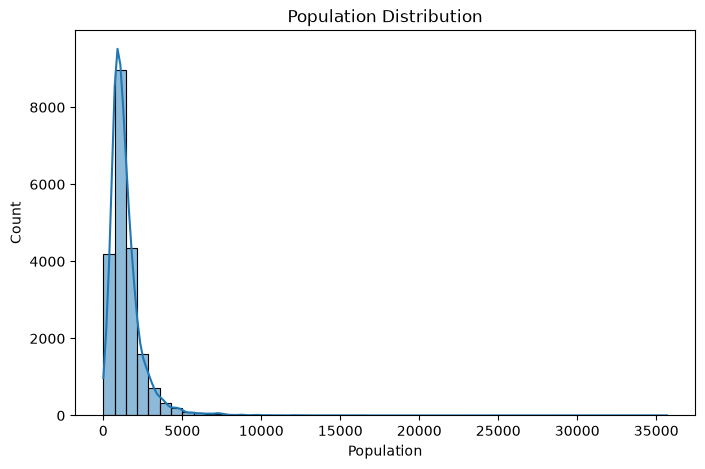

In [31]:
plt.figure(figsize=(8,5))
sns.histplot(df["Population"], bins=50, kde=True)

plt.title("Population Distribution")
plt.show()

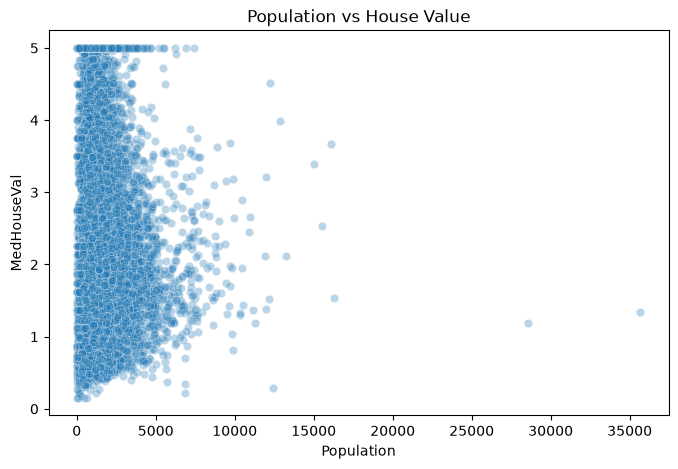

In [32]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["Population"],
    y=df["MedHouseVal"],
    alpha=0.3
)

plt.title("Population vs House Value")
plt.show()

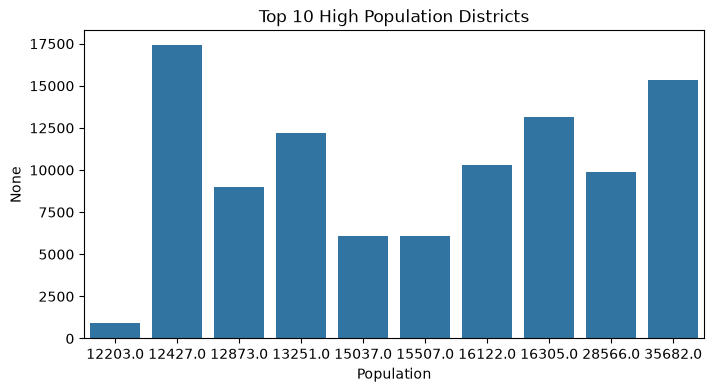

In [33]:
top10 = df.sort_values("Population", ascending=False).head(10)

plt.figure(figsize=(8,4))
sns.barplot(x=top10["Population"], y=top10.index)

plt.title("Top 10 High Population Districts")
plt.show()

In [34]:
def count_outliers(df):
    outliers = {}

    for col in df.columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        outliers[col] = ((df[col] < lower) | (df[col] > upper)).sum()

    return outliers

outlier_counts = count_outliers(df)
outlier_counts

{'MedInc': np.int64(681),
 'HouseAge': np.int64(0),
 'AveRooms': np.int64(511),
 'AveBedrms': np.int64(1424),
 'Population': np.int64(1196),
 'AveOccup': np.int64(711),
 'Latitude': np.int64(0),
 'Longitude': np.int64(0),
 'MedHouseVal': np.int64(1071)}

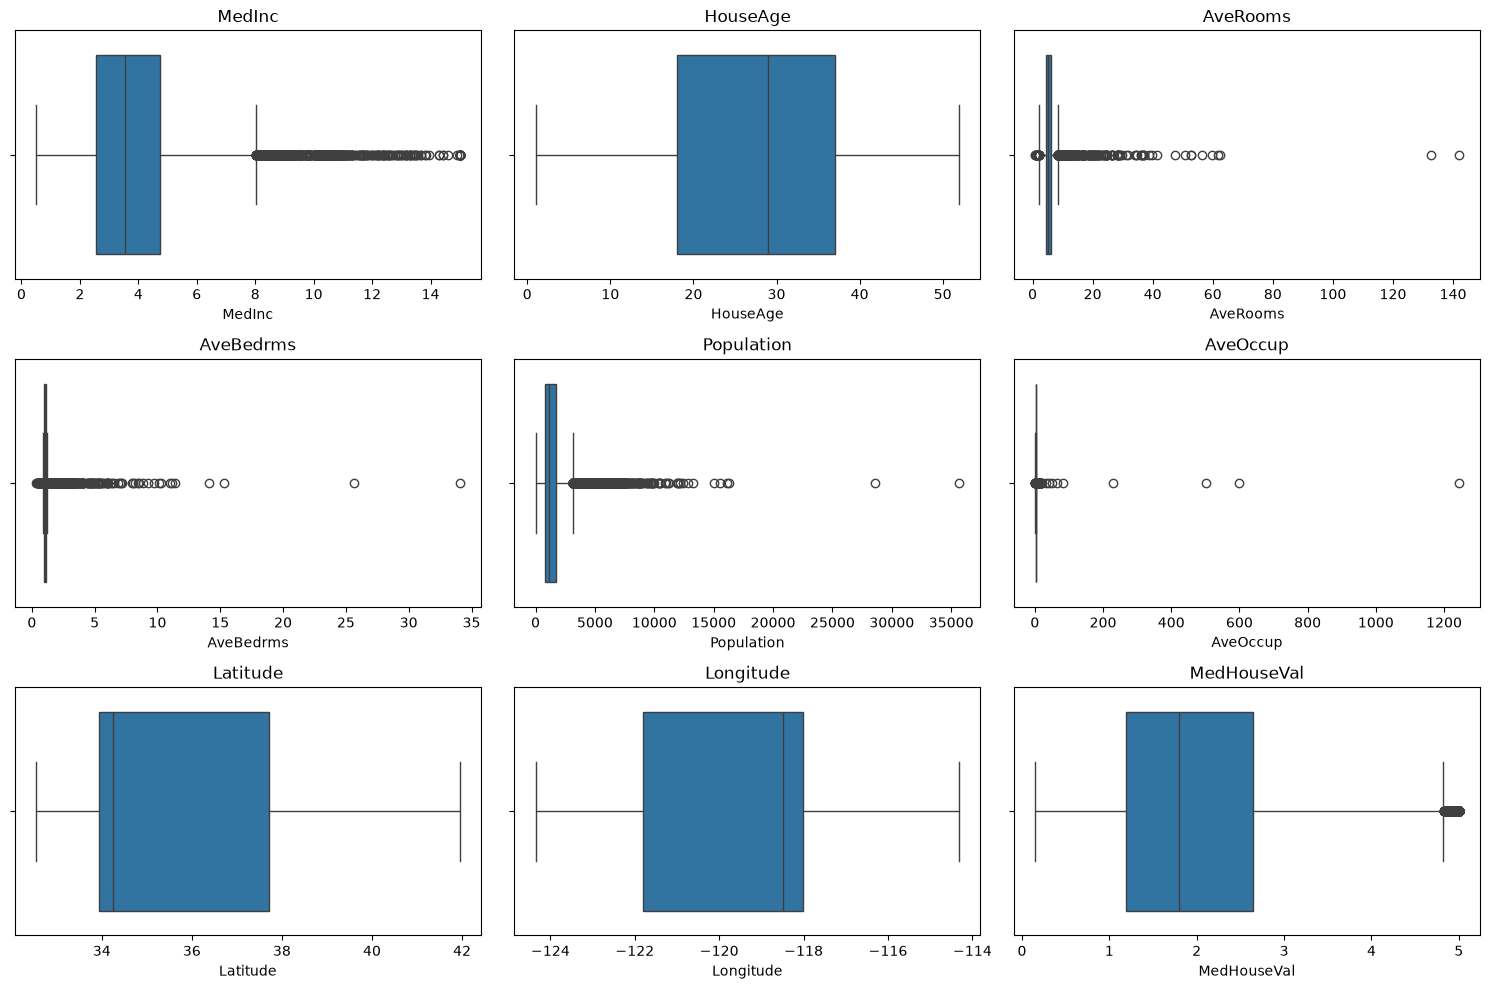

In [35]:
plt.figure(figsize=(15,10))

for i, col in enumerate(df.columns):
    plt.subplot(3, 3, i+1)
    sns.boxplot(x=df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [36]:
X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [38]:
baseline_pred = np.full(len(y_test), y_train.mean())

In [39]:
mae = mean_absolute_error(y_test, baseline_pred)
rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
r2 = r2_score(y_test, baseline_pred)

print(mae, rmse, r2)

0.9060685490007149 1.1448563543099792 -0.00021908714592466794


In [40]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [41]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

lr_pred = lr.predict(X_test_scaled)

In [42]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [43]:
results = pd.DataFrame({
    "Model": ["Baseline", "Linear Regression", "Random Forest"],
    "MAE": [
        mae,
        mean_absolute_error(y_test, lr_pred),
        mean_absolute_error(y_test, rf_pred)
    ],
    "RMSE": [
        rmse,
        np.sqrt(mean_squared_error(y_test, lr_pred)),
        np.sqrt(mean_squared_error(y_test, rf_pred))
    ],
    "R2": [
        r2,
        r2_score(y_test, lr_pred),
        r2_score(y_test, rf_pred)
    ]
})

results

,Model,MAE,RMSE,R2
0,Baseline,0.906069,1.144856,-0.000219
1,Linear Regression,0.533200,0.745581,0.575788
2,Random Forest,0.327731,0.505986,0.804624


In [44]:
X["RoomsPerHousehold"] = X["AveRooms"] / X["AveOccup"]
X["BedroomsPerRoom"] = X["AveBedrms"] / X["AveRooms"]
X["PopulationPerHousehold"] = X["Population"] / X["AveOccup"]

In [45]:
scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="r2"
)

print(scores)
print(scores.mean())

print(
    "scores:",
    scores.mean()
)

[0.51972626 0.70409012 0.73731653 0.62565783 0.68694675]
0.6547474994233484
scores: 0.6547474994233484


In [46]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None],
    "min_samples_split": [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

grid.best_params_, grid.best_score_

({'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200},
 np.float64(0.805109009947909))

In [47]:
train_scores = []
test_scores = []

depths = range(1, 25)

for d in depths:
    model = RandomForestRegressor(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))

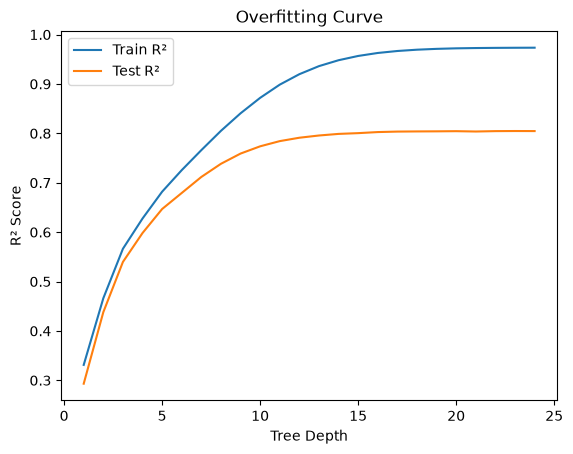

In [48]:
plt.plot(depths, train_scores, label="Train R²")
plt.plot(depths, test_scores, label="Test R²")

plt.xlabel("Tree Depth")
plt.ylabel("R² Score")
plt.title("Overfitting Curve")
plt.legend()
plt.show()

In [49]:
joblib.dump(grid.best_estimator_, "california_model.pkl")

['california_model.pkl']